In [ ]:
 !pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 66.4 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 120.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.15
    Uninstalling idna-3.15:
      Successfully uninstalled idna-3.15


In [ ]:
from ultralytics import YOLO
import os
from IPython.display import display, Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
#ambil dataset yang sudah dianotasi langsung dari roboflow
from roboflow import Roboflow
rf = Roboflow(api_key='pEzU8yDLIAJGO0pAqwZ8')
project = rf.workspace('naylaaa-abhuo').project('roi-detection-2')
version = project.version(1)
dataset = version.download('yolov11')

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov11 in progress : 0.0%
Version export complete for yolov11 format



Extracting Dataset Version Zip to ROI-Detection-2-1 in yolov11:: 100%|██████████| 435/435 [00:00<00:00, 8265.14it/s]


In [ ]:
model = YOLO('yolo11n.pt')

#training model
result = model.train(
    data=f'{dataset.location}/data.yaml',
    epochs=300,
    imgsz=640,
    plots=True,
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ROI-Detection-2-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

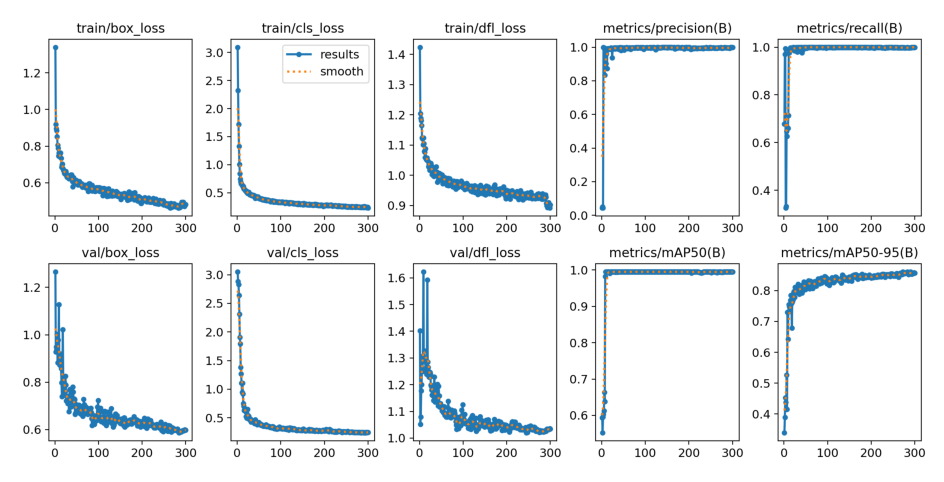

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/train/results.png")

plt.figure(figsize=(12,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
#save
import shutil
shutil.make_archive('training_yolo5', 'zip', 'runs/detect/train')

'/content/training_yolo5.zip'

In [ ]:
#download
from google.colab import files
files.download('training_yolo5.zip')
files.download('runs/detect/train/weights/best.pt')

print('Done!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


In [ ]:
import pandas as pd

metrics = model.val()

hasil = {
    "Precision": metrics.box.mp,
    "Recall": metrics.box.mr,
    "mAP@50": metrics.box.map50,
    "mAP@50-95": metrics.box.map
}

df = pd.DataFrame(
    list(hasil.items()),
    columns=["Metric", "Value"]
)

display(
    df.style
      .hide(axis="index")
      .format({"Value": "{:.3f}"})
      .set_caption("Hasil Evaluasi YOLO")
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1802.2±438.2 MB/s, size: 60.6 KB)
val: Scanning /content/ROI-Detection-2-1/valid/labels.cache... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 18.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.4it/s 2.1s
                   all         43        335      0.996      0.997      0.995      0.859
                 botol         43        117      0.998          1      0.995      0.989
                 label         40        106      0.998          1      0.995       0.94
                 tutup         42        112       0.99      0.991      0.995      0.649
Speed: 8.1ms preprocess, 17.1ms inference, 0.2ms loss, 4.8ms postprocess per image
Results saved to /content/runs/detect/val


Metric,Value
Precision,0.996
Recall,0.997
mAP@50,0.995
mAP@50-95,0.859
